In [89]:
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import country_converter as coco
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    fbeta_score,
    brier_score_loss
)

In [99]:
import os
csv_path = "data/final_clean.csv" if os.path.exists("data/final_clean.csv") else "../data/final_clean.csv"
df = pd.read_csv(csv_path)
# Check how conflict mentions vary across conflict types
type_summary = df.groupby('type_of_conflict', observed=False)['has_conflict_mention'].agg(
    count='count',
    mentions='sum',
    mention_rate='mean'
).reset_index()

print("=== Mention Rate by Conflict Type ===")
print(type_summary)

C:\Users\SemKj\AppData\Local\Temp\ipykernel_20760\1061967606.py:1: DtypeWarning: Columns (4,6,8,9,10,26,34,42,44,48,50,53,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/final_clean.csv")


=== Mention Rate by Conflict Type ===
   type_of_conflict   count  mentions  mention_rate
0                 1    8250      3840      0.465455
1                 2   21525      7767      0.360836
2                 3  319851     34066      0.106506
3                 4   88799     30667      0.345353


In [100]:
total_len = len(df)
print(f"totals len: {total_len}\n")

over_5_pct = []
under_or_equal_5_pct = []

# Group columns by missing threshold
for col in df.columns:
    missing_num = df[col].isnull().sum()
    if missing_num > 0:
        missing_pct = (missing_num / total_len) * 100
        item = (col, missing_num, missing_pct)
        if missing_pct > 15.0:
            over_5_pct.append(item)
        else:
            under_or_equal_5_pct.append(item)

# 1. Print columns with > 5% missing
print("=== Columns with MORE than 5% missing ===")
if over_5_pct:
    for col, count, pct in over_5_pct:
        print(f"Missing {col} num: {count} / {total_len} ({pct:.2f}%)")
else:
    print("None\n")

print("\n=== Columns with 5% or LESS missing ===")
if under_or_equal_5_pct:
    for col, count, pct in under_or_equal_5_pct:
        print(f"Missing {col} num: {count} / {total_len} ({pct:.2f}%)")
else:
    print("None")

totals len: 438425

=== Columns with MORE than 5% missing ===
Missing side_a_2nd num: 357275 / 438425 (81.49%)
Missing side_b_2nd num: 415773 / 438425 (94.83%)
Missing iso3_a_2nd num: 357275 / 438425 (81.49%)
Missing iso3_b num: 416900 / 438425 (95.09%)
Missing iso3_b_2nd num: 415773 / 438425 (94.83%)
Missing side_b_ideals_diff num: 420285 / 438425 (95.86%)
Missing side_b_dist num: 417975 / 438425 (95.34%)
Missing territory_name num: 199208 / 438425 (45.44%)
Missing ep_end_date num: 353102 / 438425 (80.54%)
Missing ep_end_prec num: 438425 / 438425 (100.00%)
Missing bdeadlow num: 176499 / 438425 (40.26%)
Missing bdeadhig num: 176499 / 438425 (40.26%)
Missing bdeadbes num: 270581 / 438425 (61.72%)
Missing annualdata num: 176499 / 438425 (40.26%)
Missing source num: 176499 / 438425 (40.26%)
Missing bdversion num: 176499 / 438425 (40.26%)
Missing location_prio num: 176499 / 438425 (40.26%)
Missing incomp num: 176499 / 438425 (40.26%)
Missing terr num: 296890 / 438425 (67.72%)
Missing int n

In [ ]:
# Calculate percentage of missing values per column
missing_pct = (df.isnull().sum() / len(df)) * 100

# Get list of column names with less than 15% missing
cols_under_15_pct = missing_pct[missing_pct < 15.0].index.tolist()

print("Columns with < 15% missing values:")

Columns with < 15% missing values:


In [102]:
import numpy as np
import pandas as pd

# 1. Select & Deduplicate Initial DataFrame Columns
df = df.loc[:, ~df.columns.duplicated()][[
    'country_code', 'side_a', 'conflict_id', 'year', 'has_conflict_mention',
    'intensity_level', 'cumulative_intensity', 'type_of_conflict',
    'main_actor', 'secondary_actor', 'conflict_host', 
    'side_a_ideals_diff', 'side_a_dist', 'incompatibility',
    'deaths_estimate', 'location'
]].copy()

# 2. Log-Transform Skewed Features
df['log_deaths_estimate'] = np.log1p(df['deaths_estimate'].clip(lower=0))
df['log_side_a_dist'] = np.log1p(df['side_a_dist'].clip(lower=0))

# 3. 10-Year Rolling Mean for side_a_ideals_diff per (conflict_id, country_code) entity stream
group_keys = ['conflict_id', 'country_code']
df = df.sort_values(by=group_keys + ['year']).reset_index(drop=True)

# Assign raw .values directly to avoid MultiIndex reindexing errors on duplicate years
df['side_a_ideals_diff_roll10'] = (
    df.groupby(group_keys)
      .rolling(window=10, min_periods=1, on='year')['side_a_ideals_diff']
      .mean()
      .values
)
df = df[['country_code', 'side_a', 'conflict_id', 'year', 'has_conflict_mention',
       'intensity_level', 'cumulative_intensity', 'type_of_conflict',
       'main_actor', 'secondary_actor', 'conflict_host', 'incompatibility', 'location',
       'log_deaths_estimate', 'log_side_a_dist', 'side_a_ideals_diff_roll10']]
df

,country_code,side_a,conflict_id,year,has_conflict_mention,intensity_level,cumulative_intensity,type_of_conflict,main_actor,secondary_actor,conflict_host,incompatibility,location,log_deaths_estimate,log_side_a_dist,side_a_ideals_diff_roll10
0,ALB,Government of Bolivia,200,1967,False,1,1,3,False,False,False,2.0,Bolivia,4.418841,9.299873,3.578850
1,ARG,Government of Bolivia,200,1946,True,2,1,3,False,False,False,2.0,Bolivia,6.908755,7.532002,0.295676
2,ARG,Government of Bolivia,200,1967,False,1,1,3,False,False,False,2.0,Bolivia,4.418841,7.532002,0.190701
3,AUS,Government of Bolivia,200,1946,False,2,1,3,False,False,False,2.0,Bolivia,6.908755,9.500878,0.274260
4,AUS,Government of Bolivia,200,1967,False,1,1,3,False,False,False,2.0,Bolivia,4.418841,9.500878,0.997642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330943,WSM,Government of Israel,16470,2025,False,1,0,2,False,False,False,2.0,"Israel, Yemen (North Yemen)",5.105945,9.719686,2.857813
330944,YEM,Government of Israel,16470,2025,True,1,0,2,True,False,True,2.0,"Israel, Yemen (North Yemen)",5.105945,7.687541,3.339671
330945,ZAF,Government of Israel,16470,2025,True,1,0,2,False,False,False,2.0,"Israel, Yemen (North Yemen)",5.105945,8.834130,3.263409
330946,ZMB,Government of Israel,16470,2025,False,1,0,2,False,False,False,2.0,"Israel, Yemen (North Yemen)",5.105945,8.554910,3.525904


In [103]:
# 1. Feature Definition & Type Standardization
threshold = 0.5
id_cols = ['conflict_id', 'year']
target_col = 'has_conflict_mention'

categorical_cols = ['type_of_conflict', 'incompatibility', 'country_code']
bool_cols = ['main_actor', 'secondary_actor', 'conflict_host']
numeric_cols = ['intensity_level', 'cumulative_intensity', 'side_a_ideals_diff_roll10', 
                'log_side_a_dist', 'log_deaths_estimate']

feature_cols = list(dict.fromkeys(categorical_cols + bool_cols + numeric_cols))

df = df.loc[:, ~df.columns.duplicated()].copy()
df[target_col] = df[target_col].astype(int)

for col in bool_cols:
    df[col] = df[col].astype(int)

for col in categorical_cols:
    df[col] = df[col].astype(str).astype('category')

# 2. Setup Rolling Window Parameters
start_eval_year = 2012   # First year to test on
end_eval_year = df['year'].max()

cv_results = []

print(f"Starting Walk-Forward CV from year {start_eval_year} to {end_eval_year}...\n")

# 3. Rolling Origin Loop
for test_year in range(start_eval_year, end_eval_year + 1):
    # Train on all history UP TO test_year - 1
    train_mask = df['year'] < test_year
    test_mask = df['year'] == test_year
    
    train_df = df[train_mask]
    test_df = df[test_mask]
    
    # Skip fold if test year has no target instances or missing data
    if len(test_df) == 0 or test_df[target_col].nunique() < 2:
        continue
        
    X_tr, y_tr = train_df[feature_cols], train_df[target_col]
    X_te, y_te = test_df[feature_cols], test_df[target_col]
    
    # Calculate scale_pos_weight dynamically per fold
    num_neg = (y_tr == 0).sum()
    num_pos = (y_tr == 1).sum()
    scale_weight = num_neg / num_pos if num_pos > 0 else 1.0
    
    # Initialize XGBoost Classifier
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        enable_categorical=True,
        scale_pos_weight=scale_weight,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_tr, y_tr, verbose=False)
    
    # Predict probabilities for current test_year
    probs = model.predict_proba(X_te)[:, 1]
    
    # Evaluate performance
    roc_auc = roc_auc_score(y_te, probs)
    precision, recall, _ = precision_recall_curve(y_te, probs)
    pr_auc = auc(recall, precision)

    # 2. Binary Class Predictions & Threshold-based Metrics
    preds = (probs >= threshold).astype(int)
    
    prec = precision_score(y_te, preds, zero_division=0)
    rec = recall_score(y_te, preds, zero_division=0)
    f2 = fbeta_score(y_te, preds, beta=2, zero_division=0)
    brier = brier_score_loss(y_te, probs)
    
    # 3. Store in Results List
    cv_results.append({
        'Test Year': test_year,
        'Train Size': len(train_df),
        'Test Size': len(test_df),
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Precision': prec,
        'Recall': rec,
        'F2-Score': f2,
        'Brier Score': brier
    })
    
    print(f"Year {test_year} | Train N: {len(train_df):6d} | Test N: {len(test_df):5d} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

# 4. Aggregate CV Performance
results_df = pd.DataFrame(cv_results)
print("\n=== Walk-Forward Cross-Validation Summary ===")
# Display summary statistics for all evaluated metrics
score_cols = ['ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F2-Score', 'Brier Score']
print(results_df[score_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])

Starting Walk-Forward CV from year 2012 to 2025...

Year 2012 | Train N: 205730 | Test N:  5490 | ROC-AUC: 0.8284 | PR-AUC: 0.5393
Year 2013 | Train N: 211220 | Test N:  6516 | ROC-AUC: 0.8371 | PR-AUC: 0.6062
Year 2014 | Train N: 217736 | Test N:  7826 | ROC-AUC: 0.8131 | PR-AUC: 0.5820
Year 2015 | Train N: 225562 | Test N:  9595 | ROC-AUC: 0.7935 | PR-AUC: 0.5659
Year 2016 | Train N: 235157 | Test N:  9464 | ROC-AUC: 0.8514 | PR-AUC: 0.5779
Year 2017 | Train N: 244621 | Test N:  9200 | ROC-AUC: 0.8074 | PR-AUC: 0.5927
Year 2018 | Train N: 253821 | Test N:  9016 | ROC-AUC: 0.8069 | PR-AUC: 0.5697
Year 2019 | Train N: 262837 | Test N:  9882 | ROC-AUC: 0.8244 | PR-AUC: 0.5475
Year 2020 | Train N: 272719 | Test N:  9466 | ROC-AUC: 0.8124 | PR-AUC: 0.4773
Year 2021 | Train N: 282185 | Test N:  9289 | ROC-AUC: 0.7776 | PR-AUC: 0.5027
Year 2022 | Train N: 291474 | Test N:  9727 | ROC-AUC: 0.8257 | PR-AUC: 0.5886
Year 2023 | Train N: 301201 | Test N: 10213 | ROC-AUC: 0.8283 | PR-AUC: 0.5583


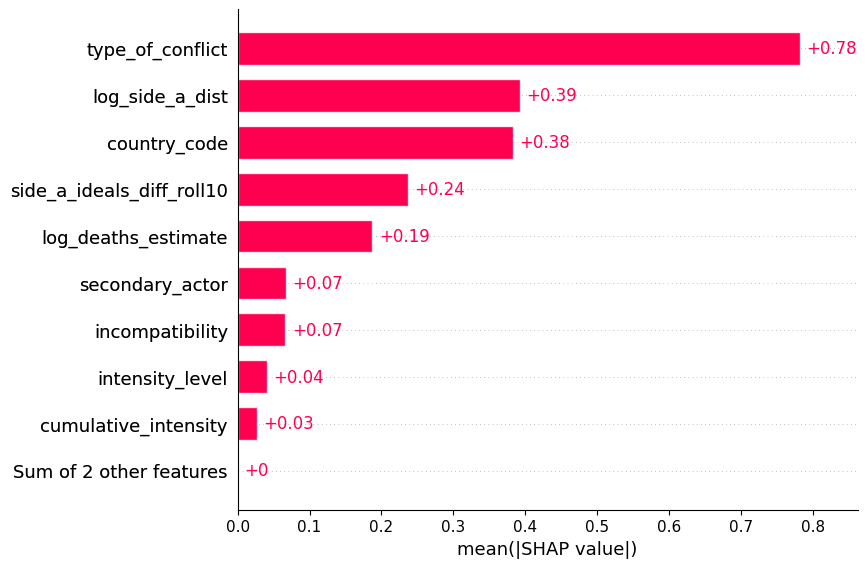

In [104]:
# 2. Compute SHAP values natively inside XGBoost C++ core
# Convert X_test into DMatrix (handles categorical types automatically)
dtest = xgb.DMatrix(X_te, enable_categorical=True)

# pred_contribs=True returns SHAP matrix of shape (n_samples, n_features + 1)
shap_contribs = model.get_booster().predict(dtest, pred_contribs=True)

# Separate feature SHAP values from the base expected value (last column)
shap_values_matrix = shap_contribs[:, :-1]
base_value = shap_contribs[0, -1]

# 3. Create a SHAP Explanation object for rich plotting compatibility
explanation = shap.Explanation(
    values=shap_values_matrix,
    base_values=base_value,
    data=X_te,
    feature_names=feature_cols
)

# 4. Plot Global Importance Bar Chart
plt.figure(figsize=(10, 6))
shap.plots.bar(explanation)
plt.show()



In [105]:
df.value_counts('type_of_conflict')

type_of_conflict
3    240432
4     71848
2     13871
1      4797
Name: count, dtype: int64

In [106]:
# Check how conflict mentions vary across conflict types
type_summary = df.groupby('type_of_conflict', observed=False)['has_conflict_mention'].agg(
    count='count',
    mentions='sum',
    mention_rate='mean'
).reset_index()

print("=== Mention Rate by Conflict Type ===")
print(type_summary)

=== Mention Rate by Conflict Type ===
  type_of_conflict   count  mentions  mention_rate
0                1    4797      2196      0.457786
1                2   13871      4637      0.334295
2                3  240432     22212      0.092384
3                4   71848     25367      0.353065


In [107]:
# Absolute counts of conflict mentions
year_df = df[df['year'] == 2022]
mention_counts = year_df['has_conflict_mention'].value_counts()

# Overall mention rate across all 330k rows
overall_rate = year_df['has_conflict_mention'].mean()

print("=== Entire Dataset Mention Summary ===")
print(f"Total Rows: {len(year_df):,}")
print(f"No Mention (0): {mention_counts.get(0, 0):,}")
print(f"Has Mention (1): {mention_counts.get(1, 0):,}")
print(f"Overall Mention Rate: {overall_rate:.4%}")

=== Entire Dataset Mention Summary ===
Total Rows: 9,727
No Mention (0): 7,899
Has Mention (1): 1,828
Overall Mention Rate: 18.7931%


array([0, 0, 0, ..., 1, 1, 1], shape=(10094,))

,type_of_conflict,incompatibility,country_code,main_actor,secondary_actor,conflict_host,intensity_level,cumulative_intensity,side_a_ideals_diff_roll10,log_side_a_dist,log_deaths_estimate
1449,3,2.0,AGO,0,0,0,1,1,0.203211,9.408453,4.955827
1484,3,2.0,ALB,0,0,0,1,1,1.482823,9.211544,4.955827
1514,3,2.0,AND,0,0,0,1,1,1.179257,9.335467,4.955827
1549,3,2.0,ARE,0,0,0,1,1,0.240166,8.860461,4.955827
1592,3,2.0,ARG,0,0,0,1,1,0.619044,9.786061,4.955827
...,...,...,...,...,...,...,...,...,...,...,...
330943,2,2.0,WSM,0,0,0,1,0,2.857813,9.719686,5.105945
330944,2,2.0,YEM,1,0,1,1,0,3.339671,7.687541,5.105945
330945,2,2.0,ZAF,0,0,0,1,0,3.263409,8.834130,5.105945
330946,2,2.0,ZMB,0,0,0,1,0,3.525904,8.554910,5.105945


NameError: name 'Y_te' is not defined